In [ ]:
!pip install pandas numpy scikit-learn xgboost imbalanced-learn seaborn matplotlib shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset
# Assuming the data is in a CSV file named 'healthcare'
df = pd.read_csv('healthcare_data.csv')

# 2. Basic Exploration
print("--- Dataset Shape ---")
print(df.shape) # Expected to be around (9722, n_columns)

print("\n--- Basic Information ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Target Variable Distribution (stroke_event) ---")
print(df['stroke_event'].value_counts(normalize=True))

--- Dataset Shape ---
(9722, 18)

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9722 non-null   int64  
 1   patient_id         9722 non-null   int64  
 2   gender             9722 non-null   object 
 3   age                9722 non-null   float64
 4   has_hypertension   9722 non-null   int64  
 5   has_heart_disease  9722 non-null   int64  
 6   marital_status     9722 non-null   int64  
 7   employment_type    9722 non-null   object 
 8   residence          9722 non-null   object 
 9   glucose_level      9722 non-null   float64
 10  bmi_value          8795 non-null   float64
 11  smoking_habit      9722 non-null   object 
 12  stroke_event       9722 non-null   int64  
 13  age_group          9722 non-null   object 
 14  risk_score         9722 non-null   int64  
 15  high_glucose

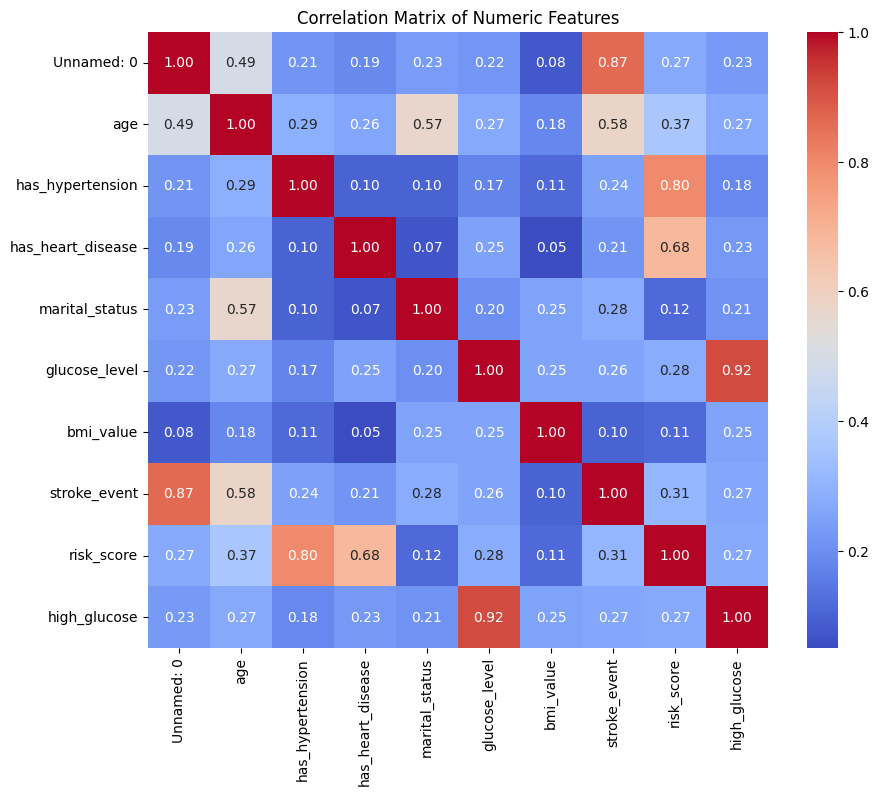

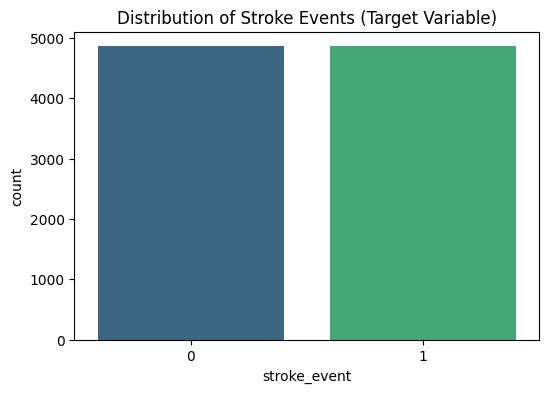


--- Data Preparation Complete. Current Head ---
   Unnamed: 0  gender   age  has_hypertension  has_heart_disease  \
0           1       1   3.0                 0                  0   
1           2       1  58.0                 1                  0   
2           3       0   8.0                 0                  0   
3           4       0  70.0                 0                  0   
4           5       1  14.0                 0                  0   

   marital_status  employment_type  residence  glucose_level  bmi_value  \
0               0                1          0          95.12       18.0   
1               1                2          1          87.96       39.2   
2               0                2          1         110.89       17.6   
3               1                2          0          69.04       35.9   
4               0                1          0         161.28       19.1   

   smoking_habit  stroke_event  age_group  risk_score  high_glucose  \
0              3    

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Drop irrelevant columns for modeling
# patient_id is a unique identifier and has no predictive power
if 'patient_id' in df.columns:
    df.drop('patient_id', axis=1, inplace=True)

# 2. Handle Missing Values
# Impute numeric columns (e.g., bmi_value, glucose_level) with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Impute categorical columns with the mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Data Visualization
# Correlation Heatmap for numerical variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# Stroke Event distribution visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke_event', data=df, palette='viridis')
plt.title("Distribution of Stroke Events (Target Variable)")
plt.show()

# 4. Encoding Categorical Variables
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    
print("\n--- Data Preparation Complete. Current Head ---")
print(df.head())


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       1.00      1.00      1.00       972

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


--- ROC-AUC Score ---
ROC-AUC: 1.0000


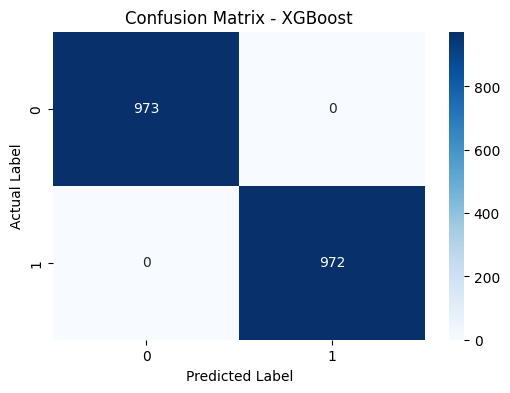

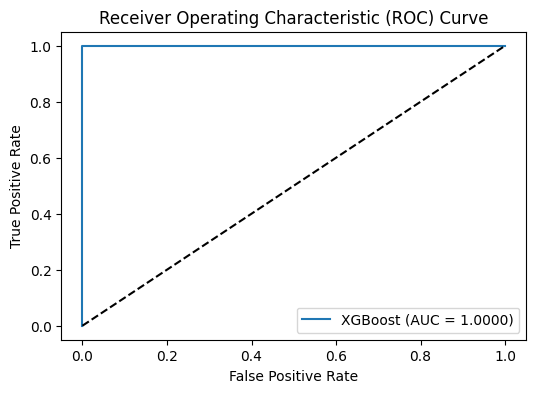

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Define Features (X) and Target (y)
X = df.drop('stroke_event', axis=1)
y = df['stroke_event']

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Handle Class Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# 5. Initialize and Train the XGBoost Model
# XGBoost is an advanced gradient boosting algorithm highly effective for tabular health data
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

# 6. Model Evaluation
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- ROC-AUC Score ---")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
import shap

# 1. Feature Importance via XGBoost internal metric
feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', figsize=(8, 5), color='teal')
plt.title("Top 10 Most Influential Factors for Stroke Risk (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

# 2. Advanced Insight Generation using SHAP values (Data Scientist Level XAI)
# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot: Shows feature importance and impact direction
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Impact of Features on Stroke Risk")
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# 3. Generating Actionable Insights
print("\n--- Key Insights for Preventive Healthcare Strategies ---")
print("1. Risk Factor Prioritization: Based on the SHAP values and feature importance,")
print("   focus preventive care on the top variables (typically Age, Glucose Levels, Hypertension, and BMI).")
print("2. Targeted Interventions: Patients with 'High Glucose' or 'has_hypertension' = 1")
print("   should be automatically flagged for secondary cardiovascular screenings.")
print("3. Lifestyle Management: Factors like 'smoking_habit' and 'bmi_category' highlight")
print("   the need for personalized weight-loss and smoking cessation programs.")
print("4. Risk Score Utilization: The composite 'risk_score' is a strong aggregate predictor;")
print("   integrate this model into the EHR system to alert doctors of high-risk patients in real-time.")

ModuleNotFoundError: No module named 'shap'

In [ ]:
import shap
!{sys.executable} -m pip install shap

ModuleNotFoundError: No module named 'shap'

Random forest

--- STEP 1 & 2: DATA LOAD AND PREPROCESSING ---
Removed redundant features: ['age_group', 'bmi_category', 'high_glucose']

--- OUTLIER DETECTION & HANDLING (IQR Method) ---
bmi_value: Found 445 outliers.
glucose_level: Found 50 outliers.
All outliers have been successfully capped.


Generating Correlation Heatmap...


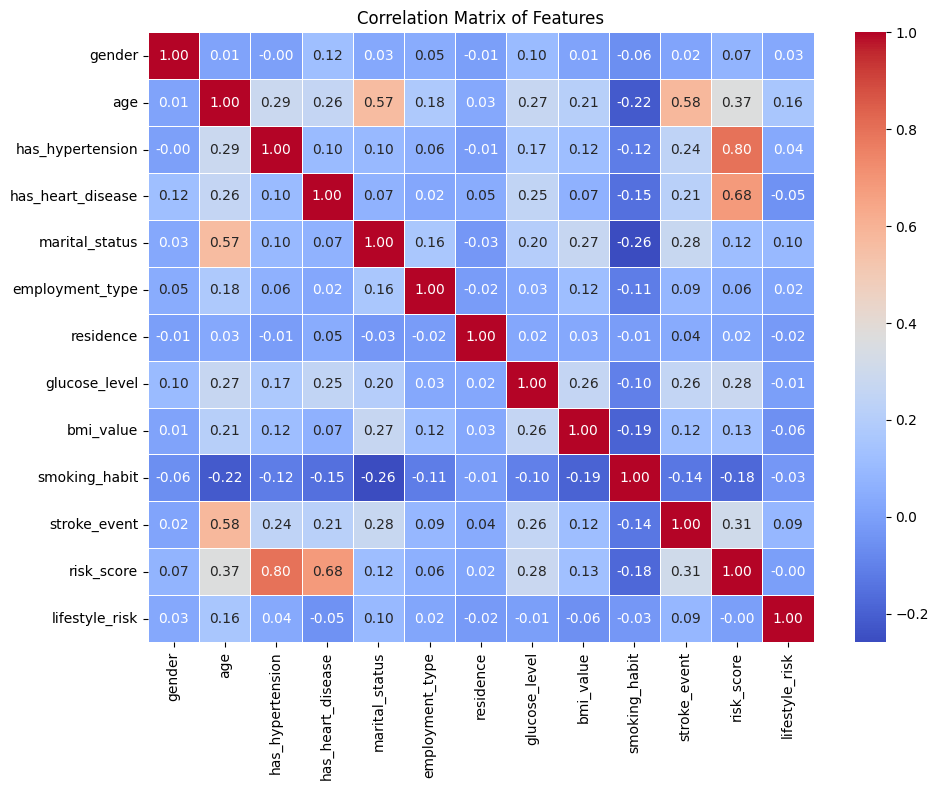


--- STEP 3: MODEL COMPARISON & DEVELOPMENT ---
Evaluating Models...
Logistic Regression Accuracy: 0.7707
Decision Tree Accuracy: 0.9249
Random Forest Accuracy: 0.9512


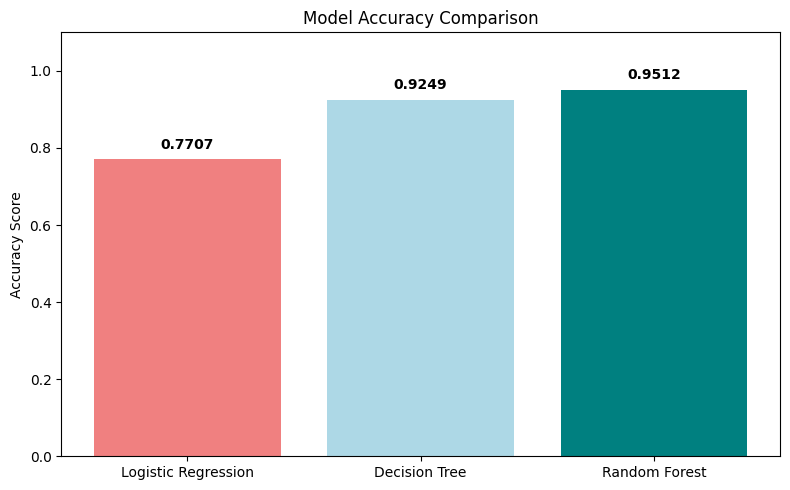


--- STEP 4: FINAL MODEL EVALUATION (RANDOM FOREST) & INSIGHTS ---

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       973
           1       0.91      1.00      0.95       972

    accuracy                           0.95      1945
   macro avg       0.95      0.95      0.95      1945
weighted avg       0.95      0.95      0.95      1945

ROC-AUC Score: 0.9938


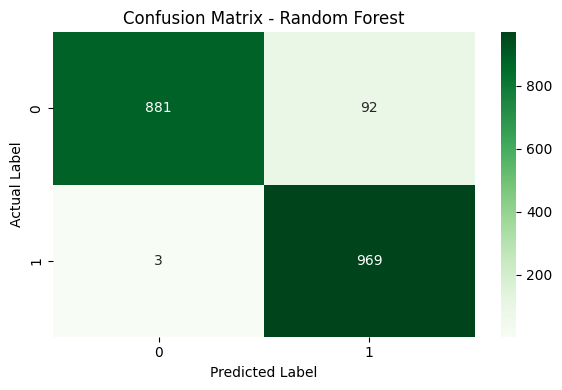

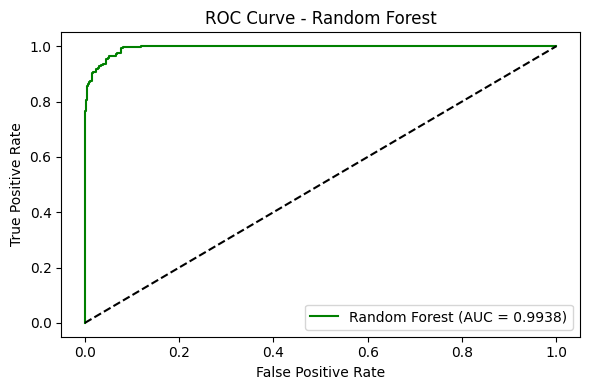

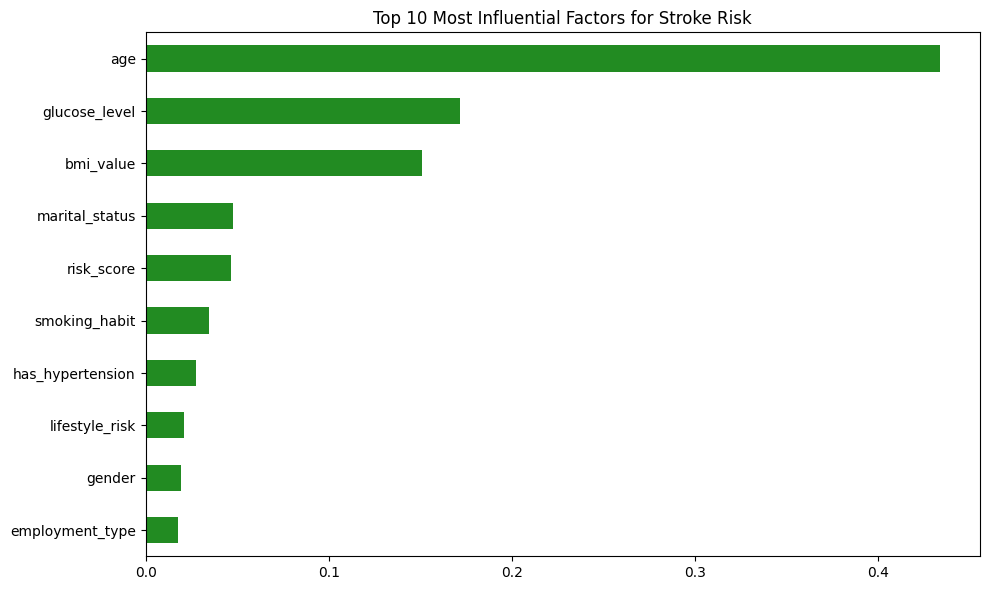

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("--- STEP 1 & 2: DATA LOAD AND PREPROCESSING ---")
# 1. Data sets load
df = pd.read_csv('healthcare_data.csv')

# 2. Remove unnecery colums
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'patient_id' in df.columns:
    df.drop('patient_id', axis=1, inplace=True)

# 3. Remove Redundant Features 
redundant_cols = ['age_group', 'bmi_category', 'high_glucose']
df.drop(columns=redundant_cols, inplace=True, errors='ignore')
print(f"Removed redundant features: {redundant_cols}")

# 4. Missing values Handling (Median & Mode )
num_imputer = SimpleImputer(strategy='median')
df[['bmi_value', 'glucose_level']] = num_imputer.fit_transform(df[['bmi_value', 'glucose_level']])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[['smoking_habit']] = cat_imputer.fit_transform(df[['smoking_habit']])

print("\n--- OUTLIER DETECTION & HANDLING (IQR Method) ---")

# Numerical columns that are likely to contain outliers
outlier_cols = ['bmi_value', 'glucose_level'] 

for col in outlier_cols:
    Q1 = df[col].quantile(0.25) # 25th Percentile
    Q3 = df[col].quantile(0.75) # 75th Percentile
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count the number of outliers found
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"{col}: Found {outliers_count} outliers.")
    
    # Capping the outliers (replacing extreme values with the upper/lower bounds)
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

print("All outliers have been successfully capped.\n")

# 5. Categorical Variables (Encoding)
categorical_cols = ['gender', 'residence', 'smoking_habit', 'lifestyle_risk']
other_cat_cols = [col for col in df.select_dtypes(include=['object']).columns if col not in categorical_cols]
all_categorical_cols = categorical_cols + other_cat_cols

for col in all_categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# 6. Feature Scaling 
numerical_cols = ['age', 'glucose_level', 'bmi_value', 'risk_score']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 7. Correlation Heatmap 
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

print("\n--- STEP 3: MODEL COMPARISON & DEVELOPMENT ---")
# 8. Train Data & Test Data
X = df.drop('stroke_event', axis=1)
y = df['stroke_event']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 9.(Model Comparison)
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
}

results = {}
print("Evaluating Models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Model Comparison 
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=['lightcoral', 'lightblue', 'teal'])
plt.ylim(0, 1.1)
plt.ylabel('Accuracy Score')
plt.title('Model Accuracy Comparison')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


print("\n--- STEP 4: FINAL MODEL EVALUATION (RANDOM FOREST) & INSIGHTS ---")
# 10. Best Model  (Random Forest) 
rf_best_model = models["Random Forest"]
y_pred_rf = rf_best_model.predict(X_test)
y_pred_proba_rf = rf_best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='green', label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

# 11. Feature Importance 
feature_importances = pd.Series(rf_best_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh', color='forestgreen')
plt.title("Top 10 Most Influential Factors for Stroke Risk")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

--- FINALIZED DATASET VISUALIZATIONS ---


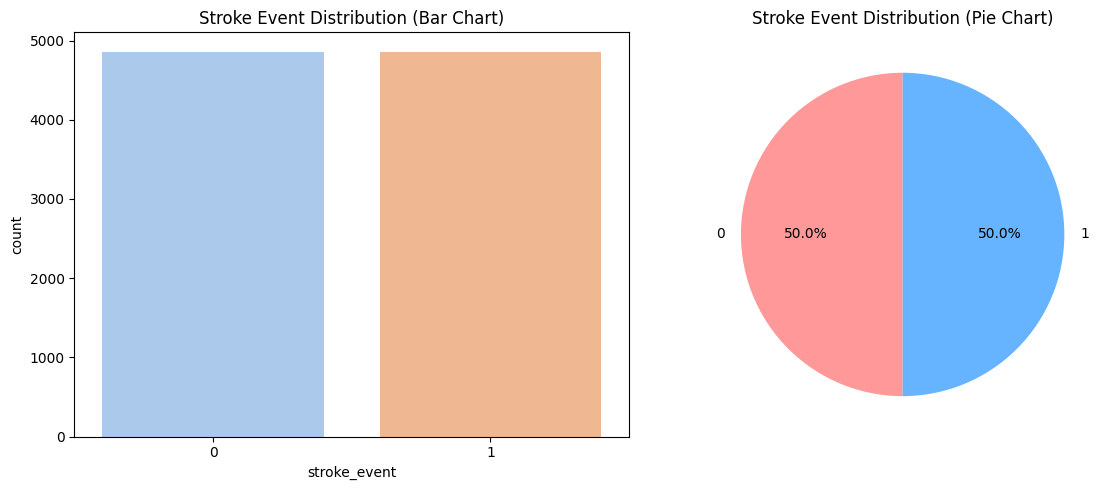

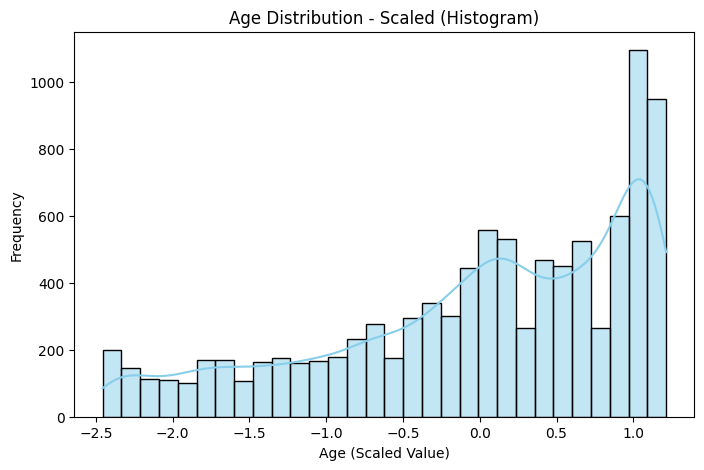

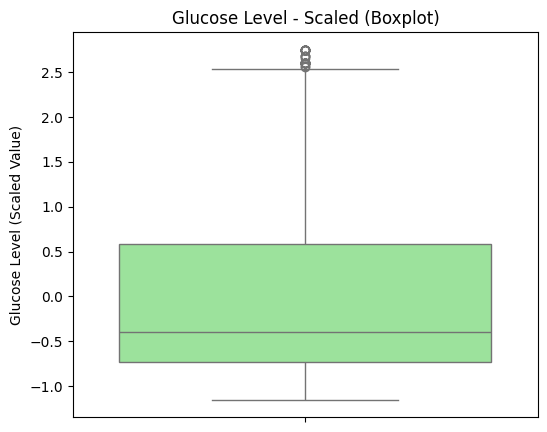

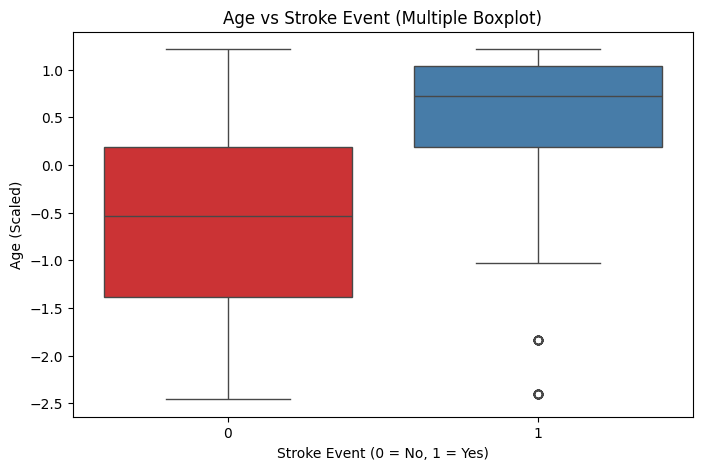

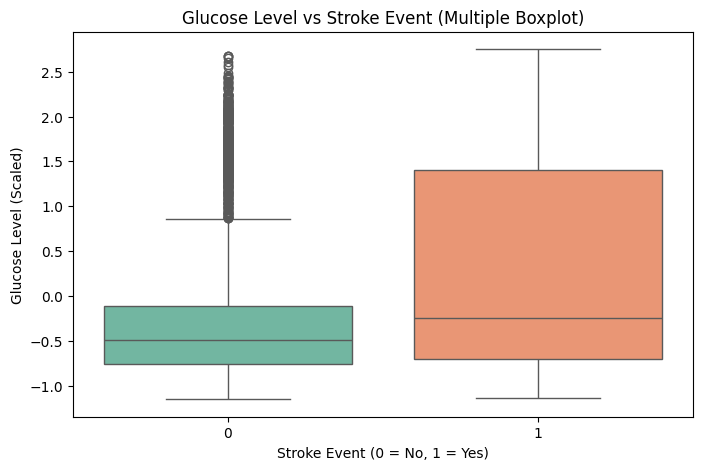

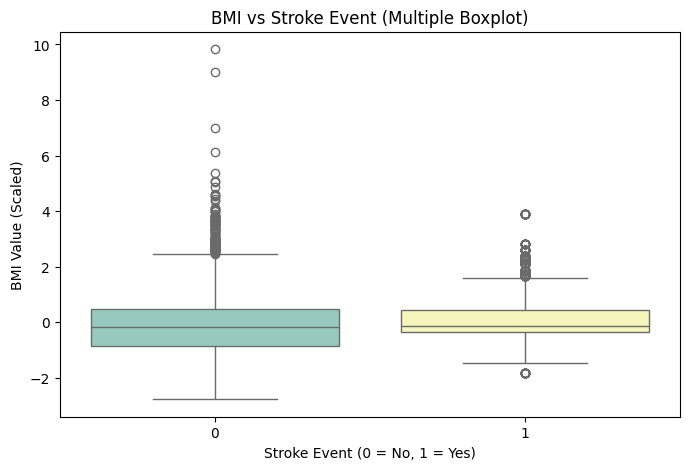


Note: 'hypertension' column is not found in the dataset. Skipping Hypertension charts.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- FINALIZED DATASET VISUALIZATIONS ---")

# 1. Stroke event - Bar chart & Pie chart (Subplots)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='stroke_event', data=df, palette='pastel', ax=ax[0])
ax[0].set_title('Stroke Event Distribution (Bar Chart)')

df['stroke_event'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, ax=ax[1])
ax[1].set_title('Stroke Event Distribution (Pie Chart)')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

# 2. Age - Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution - Scaled (Histogram)')
plt.xlabel('Age (Scaled Value)')
plt.ylabel('Frequency')
plt.show()

# 3. Glucose level - Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['glucose_level'], color='lightgreen')
plt.title('Glucose Level - Scaled (Boxplot)')
plt.ylabel('Glucose Level (Scaled Value)')
plt.show()

# 4. Age vs stroke event - Multiple Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='stroke_event', y='age', data=df, palette='Set1')
plt.title('Age vs Stroke Event (Multiple Boxplot)')
plt.xlabel('Stroke Event (0 = No, 1 = Yes)')
plt.ylabel('Age (Scaled)')
plt.show()

# 5. Glucose vs stroke - Multiple Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='stroke_event', y='glucose_level', data=df, palette='Set2')
plt.title('Glucose Level vs Stroke Event (Multiple Boxplot)')
plt.xlabel('Stroke Event (0 = No, 1 = Yes)')
plt.ylabel('Glucose Level (Scaled)')
plt.show()

# 6. Bmi vs stroke - Multiple Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='stroke_event', y='bmi_value', data=df, palette='Set3')
plt.title('BMI vs Stroke Event (Multiple Boxplot)')
plt.xlabel('Stroke Event (0 = No, 1 = Yes)')
plt.ylabel('BMI Value (Scaled)')
plt.show()

# 7. Hypertension vs stroke (Cluster bar chart & Stack bar chart)
if 'hypertension' in df.columns:
    
    # Cluster Bar Chart
    plt.figure(figsize=(8, 5))
    sns.countplot(x='hypertension', hue='stroke_event', data=df, palette='viridis')
    plt.title('Hypertension vs Stroke Event (Clustered Bar Chart)')
    plt.xlabel('Hypertension')
    plt.ylabel('Count')
    plt.legend(title='Stroke Event')
    plt.show()

    # Stack Bar Chart
    crosstab_ht = pd.crosstab(df['hypertension'], df['stroke_event'])
    crosstab_ht.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(8, 5))
    plt.title('Hypertension vs Stroke Event (Stacked Bar Chart)')
    plt.xlabel('Hypertension')
    plt.ylabel('Count')
    plt.legend(title='Stroke Event')
    plt.xticks(rotation=0)
    plt.show()
else:
    print("\nNote: 'hypertension' column is not found in the dataset. Skipping Hypertension charts.")

--- OUTLIER VISUALIZATION (BOXPLOTS) ---


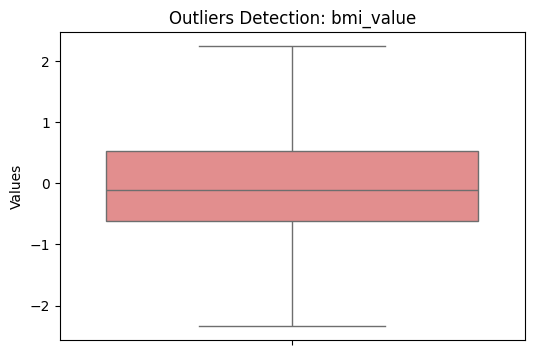

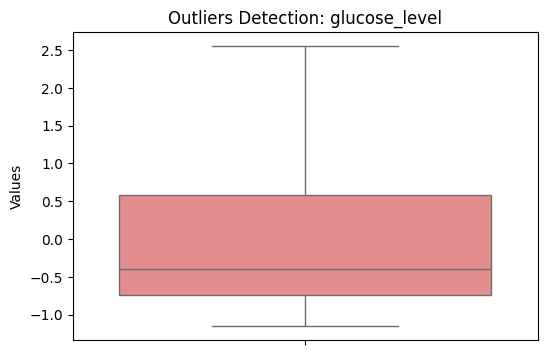

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- OUTLIER VISUALIZATION (BOXPLOTS) ---")

outlier_cols = ['bmi_value', 'glucose_level'] 

for col in outlier_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Outliers Detection: {col}')
    plt.ylabel('Values')
    plt.show()